# MCA - Multiple Correspondence Analysis : detect profiles in the population



ACM : Analyse factorielle des correspondances multiples



!!! Compléter les références !!!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import sqlite3 as sql

In [2]:
from fanalysis.ca import CA 
from fanalysis.mca import MCA

In [3]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [4]:

import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [5]:
### Use this pnéy to reload the functions if modified
# print(reload(bl))
# print(reload(cal))  

## Import the data and prepare the analysis

In this notebook, we use the data produced with the [bivariate analysis notebook using countries](da3-1_countries_bivariate_analysis.ipynb) and the data collected in the [da5-employer.md](../../documentation/wikidata/data-analysis/da5-employer.md) and [da5-employer.sql](../../documentation/wikidata/data-analysis/da5-employer.sql) files.



In [6]:
csv_address='da4-AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0,Nord,1909.0,1907-1926


In [7]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   uriPer              561 non-null    object 
 1   labelPer            559 non-null    object 
 2   birthYear           561 non-null    float64
 3   gender              561 non-null    object 
 4   labelPlace          561 non-null    object 
 5   geometry            561 non-null    object 
 6   uriPlace            561 non-null    object 
 7   periods             561 non-null    object 
 8   index_right         561 non-null    float64
 9   reg_name            561 non-null    object 
 10  reg_istat_code_num  561 non-null    float64
 11  reg_istat_code      561 non-null    float64
 12  coded_Region        561 non-null    object 
 13  activityYear        561 non-null    float64
 14  periodsActivity     561 non-null    object 
dtypes: float64(5), object(10)
memory usage: 66.0+ KB


In [8]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [9]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926


In [10]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

In [11]:
### Import the new qualitative values to be added: occupation and employer class
csv_address='da5-persons-feature.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes
0,1,http://www.wikidata.org/entity/Q104599786,politico,professore-universitario,medico,NaN,indipendente,NaN,1,NaN
1,2,http://www.wikidata.org/entity/Q105296748,NaN,economista,banchiere,NaN,indipendente,NaN,2,NaN
2,3,http://www.wikidata.org/entity/Q105320865,NaN,professore-universitario,economista,NaN,indipendente,NaN,3,NaN
3,4,http://www.wikidata.org/entity/Q1053876,politico,avvocato,giornalista,NaN,Partito Repubblicano Italiano,NaN,4,NaN
4,5,http://www.wikidata.org/entity/Q1055104,politico,ingegnere,imprenditore,NaN,Forza Italia,NaN,5,NaN


In [12]:
import pandas as pd

csv_address = 'da5-persons-feature.csv'

# 1. Leggiamo il file una sola volta. 
# Se vuoi che 'NA' venga trattato come testo normale (es. la sigla di Napoli o Namibia)
# e NON come un valore mancante, usiamo keep_default_na=False e definiamo i veri valori vuoti.
df_pfeat = pd.read_csv(
    csv_address, 
    na_values=['', 'N/A', 'NULL', 'None', 'NA', 'NaN'], 
    keep_default_na=False
)

# 2. Sostituiamo tutti i valori NaN/vuoti con la stringa "mancante"
# Usiamo inplace=True per applicare la modifica direttamente sul DataFrame esistente
df_pfeat.fillna('mancante', inplace=True)

# Mostra le prime righe per verificare il risultato
df_pfeat.head()

/tmp/ipykernel_142/3699795051.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'mancante' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_pfeat.fillna('mancante', inplace=True)


,pk_person_features,person_uri,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes
0,1,http://www.wikidata.org/entity/Q104599786,politico,professore-universitario,medico,mancante,indipendente,mancante,1,mancante
1,2,http://www.wikidata.org/entity/Q105296748,mancante,economista,banchiere,mancante,indipendente,mancante,2,mancante
2,3,http://www.wikidata.org/entity/Q105320865,mancante,professore-universitario,economista,mancante,indipendente,mancante,3,mancante
3,4,http://www.wikidata.org/entity/Q1053876,politico,avvocato,giornalista,mancante,Partito Repubblicano Italiano,mancante,4,mancante
4,5,http://www.wikidata.org/entity/Q1055104,politico,ingegnere,imprenditore,mancante,Forza Italia,mancante,5,mancante


In [13]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pk_person_features  576 non-null    int64 
 1   person_uri          576 non-null    object
 2   occupation_main     576 non-null    object
 3   occupation_sec1     576 non-null    object
 4   occupation_sec2     576 non-null    object
 5   party_main          576 non-null    object
 6   party_sec1          576 non-null    object
 7   party_sec2          576 non-null    object
 8   fk_person           576 non-null    int64 
 9   notes               576 non-null    object
dtypes: int64(2), object(8)
memory usage: 45.1+ KB


In [14]:
## Merge the two dataframes
df_pm = pd.merge(df_p,df_pfeat, on='person_uri')  
# following part was used for inspection
# , how='left')

In [15]:
## The small number depends on the considered countries
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   person_uri          561 non-null    object 
 1   labelPer            559 non-null    object 
 2   birthYear           561 non-null    float64
 3   gender              561 non-null    object 
 4   labelPlace          561 non-null    object 
 5   geometry            561 non-null    object 
 6   uriPlace            561 non-null    object 
 7   periods             561 non-null    object 
 8   index_right         561 non-null    float64
 9   reg_name            561 non-null    object 
 10  reg_istat_code_num  561 non-null    float64
 11  reg_istat_code      561 non-null    float64
 12  coded_Region        561 non-null    object 
 13  activityYear        561 non-null    float64
 14  periodsActivity     561 non-null    object 
 15  pk_person_features  561 non-null    int64  
 16  occupati

### Manage secondary occupation

We will have to code a part of the categories because their number is too small, which makes the variable too sparse.

In [16]:
### Group and count: secondary occupation
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(len(df_count))
print(df_count.iloc[:50])

40
                                    number
occupation_sec1                           
mancante                               189
avvocato                                79
professore-universitario                61
economista                              44
giornalista                             44
giurista                                18
partigiano                              17
diplomatico                             13
personalità-del-mondo-degli-affari      11
ingegnere                               11
medico                                  10
sindacalista                            10
insegnante                               8
giudice                                  5
magistrato                               3
ministro                                 3
storico                                  3
scrittore                                3
ufficiale                                3
dirigente-d'azienda                      2
imprenditore                             2
funziona

In [17]:
## We only take the first 19 elements in the list, the more interesting ones
lc = df_count[df_count.number > 1].index.to_list()
print(lc)


['mancante', 'avvocato', 'professore-universitario', 'economista', 'giornalista', 'giurista', 'partigiano', 'diplomatico', 'personalità-del-mondo-degli-affari', 'ingegnere', 'medico', 'sindacalista', 'insegnante', 'giudice', 'magistrato', 'ministro', 'storico', 'scrittore', 'ufficiale', "dirigente-d'azienda", 'imprenditore', 'funzionario', 'banchiere', 'sociologo']


In [18]:
import pandas as pd

def codeSecOccupation(occupation):
    # Se il valore è nullo (NaN) o non è una stringa, lo restituisce così com'è senza toccarlo
    if pd.isna(occupation) or not isinstance(occupation, str):
        return occupation

    if 'professore-universitario' in occupation \
        or 'insegnante' in occupation :
        output='professore'
    elif 'personalità-del-mondo-degli-affari' in occupation \
        or 'banchiere' in occupation \
        or "dirigente-d'azienda" in occupation \
        or 'imprenditore' in occupation:
        output='imprenditore'
    elif 'medico' in occupation \
        or 'dentista' in occupation \
        or 'chirurgo' in occupation \
        or 'radiologo' in occupation \
        or 'direttore-sanitario' in occupation:
        output='medico'
    elif 'giornalista' in occupation \
        or 'giornalista-pubblicista' in occupation:
        output='giornalista'
    elif 'ufficiale' in occupation \
         or 'agente-di-polizia' in occupation:
        output='ufficiale'
    elif 'accademico' in occupation \
        or 'sociologo' in occupation \
        or 'autore' in occupation \
        or 'prefattore' in occupation \
        or 'prefetto' in occupation:
        output= 'accademico' 
    elif 'agronomo' in occupation \
         or 'attore' in occupation \
         or 'geografo' in occupation \
         or 'fisico' in occupation \
         or 'danzatore' in occupation \
         or 'militare' in occupation:
        output='altro'
    elif 'giudice' in occupation \
        or 'magistrato' in occupation:
        output='giudice'
    else:
        output=occupation
    return output

In [19]:
# Usa df_pm al posto di df_p
df_pm['codedSecOccupation'] = df_pm['occupation_sec1'].map(codeSecOccupation)

In [20]:
### Group and count: secondary occupation
# We observe the results of the codind
df_count = df_pm.groupby('codedSecOccupation').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count)


                    number
codedSecOccupation        
mancante               189
avvocato                79
professore              69
giornalista             45
economista              44
giurista                18
partigiano              17
imprenditore            17
medico                  14
diplomatico             13
ingegnere               11
sindacalista            10
giudice                  8
altro                    6
accademico               6
ufficiale                4
scrittore                3
ministro                 3
storico                  3
funzionario              2


In [21]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,codedSecOccupation
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,355,politico,sindacalista,mancante,mancante,Partito Socialista Italiano,mancante,355,mancante,sindacalista
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,461,politico,diplomatico,mancante,mancante,Partito Repubblicano Italiano,mancante,461,mancante,diplomatico
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0,Nord,1909.0,1907-1926,331,politico,mancante,mancante,mancante,Partito Popolare Italiano,mancante,331,mancante,mancante


## MCA

In [22]:
data_cat = df_pm[['gender', 'coded_Region', 'occupation_sec1', 'party_sec1']]
data_cat.head(3)


,gender,coded_Region,occupation_sec1,party_sec1
0,maschio,Nord,sindacalista,Partito Socialista Italiano
1,maschio,Centro,diplomatico,Partito Repubblicano Italiano
2,maschio,Nord,mancante,Partito Popolare Italiano


In [23]:
DActives=data_cat

In [24]:
# We inspect the table that will be analysed
p = DActives.shape[1]
#nombre d'observations
n = DActives.shape[0]
print('Number of variables:', p, ' -- Nomber of individuals (rows):', n)
#codage en 0/1


Number of variables: 4  -- Nomber of individuals (rows): 561


### Complete disjunctive table 

Sometimes also referred to as a dummy variable matrix or indicator matrix.

In the context of Multiple Correspondence Analysis (MCA), this table is used to transform qualitative (categorical) variables into a quantitative format suitable for analysis. Each category of a qualitative variable becomes a separate binary column (0 or 1), indicating the absence or presence of that category for each individual.

In [25]:
## Complete disjunctive table
X = pd.get_dummies(DActives,prefix='',prefix_sep='')*1
X.head(3)

,femmina,maschio,Centro,Nord,Sud,accademico,agente-di-polizia,agronomo,attore,autore,avvocato,banchiere,chirurgo,danzatore,dentista,diplomatico,direttore-sanitario,dirigente-d'azienda,economista,fisico,funzionario,geografo,giornalista,giornalista-pubblicista,giudice,giurista,imprenditore,ingegnere,insegnante,magistrato,mancante,medico,militare,ministro,partigiano,personalità-del-mondo-degli-affari,prefattore,prefetto,professore-universitario,radiologo,scrittore,sindacalista,sociologo,storico,ufficiale,Alleanza Nazionale,Alternativa Popolare,Centro Democratico,Democratici di Sinistra,Democrazia Cristiana,Federazione dei Verdi,Forza Italia,Fratelli d'Italia,Identità e Azione,Il Popolo della Libertà,Italia Viva,Italia dei Valori,L'Ulivo,Lega Nord,Movimento 5 Stelle,Movimento Sociale Italiano,Nuovo Centrodestra,Partito Comunista Italiano,Partito Democratico,Partito Democratico del Lavoro,Partito Liberale Italiano,Partito Nazionale Fascista,Partito Popolare Italiano,Partito Radicale,Partito Repubblicano Italiano,Partito Socialista Democratico Italiano,Partito Socialista Italiano,Partito Socialista Italiano di Unità Proletaria,Partito d'Azione,Partito della Rifondazione Comunista,Rosa nel Pugno,Scelta Civica,Unione di Centro (2002),indipendente,sinistra indipendente
0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
### Nombre total de modalités, toute variable confondue
M = X.shape[1]
print('Number of categories:', M)
#nombre max de facteurs
Hmax = M-p
print('Maximum number of factors:', Hmax)

Number of categories: 80
Maximum number of factors: 76


In [27]:
Xm = X.copy(deep=True)
#Total sum per row: 
Xm.loc[:,'Total'] = Xm.sum(axis=1)
#Total sum per column: 
Xm.loc['Total',:] = Xm.sum(axis=0)
Xm.tail()

,femmina,maschio,Centro,Nord,Sud,accademico,agente-di-polizia,agronomo,attore,autore,avvocato,banchiere,chirurgo,danzatore,dentista,diplomatico,direttore-sanitario,dirigente-d'azienda,economista,fisico,funzionario,geografo,giornalista,giornalista-pubblicista,giudice,giurista,imprenditore,ingegnere,insegnante,magistrato,mancante,medico,militare,ministro,partigiano,personalità-del-mondo-degli-affari,prefattore,prefetto,professore-universitario,radiologo,scrittore,sindacalista,sociologo,storico,ufficiale,Alleanza Nazionale,Alternativa Popolare,Centro Democratico,Democratici di Sinistra,Democrazia Cristiana,Federazione dei Verdi,Forza Italia,Fratelli d'Italia,Identità e Azione,Il Popolo della Libertà,Italia Viva,Italia dei Valori,L'Ulivo,Lega Nord,Movimento 5 Stelle,Movimento Sociale Italiano,Nuovo Centrodestra,Partito Comunista Italiano,Partito Democratico,Partito Democratico del Lavoro,Partito Liberale Italiano,Partito Nazionale Fascista,Partito Popolare Italiano,Partito Radicale,Partito Repubblicano Italiano,Partito Socialista Democratico Italiano,Partito Socialista Italiano,Partito Socialista Italiano di Unità Proletaria,Partito d'Azione,Partito della Rifondazione Comunista,Rosa nel Pugno,Scelta Civica,Unione di Centro (2002),indipendente,sinistra indipendente,Total
557,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
558,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
559,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
560,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
Total,59.0,502.0,127.0,257.0,177.0,1.0,1.0,1.0,1.0,1.0,79.0,2.0,1.0,1.0,1.0,13.0,1.0,2.0,44.0,1.0,2.0,1.0,44.0,1.0,5.0,18.0,2.0,11.0,8.0,3.0,189.0,10.0,1.0,3.0,17.0,11.0,1.0,1.0,61.0,1.0,3.0,10.0,2.0,3.0,3.0,9.0,2.0,1.0,1.0,180.0,3.0,31.0,7.0,1.0,9.0,4.0,1.0,1.0,18.0,14.0,1.0,1.0,12.0,64.0,1.0,20.0,1.0,4.0,1.0,16.0,22.0,46.0,1.0,4.0,1.0,1.0,6.0,3.0,73.0,1.0,2244.0


## MCA

The Complete disjoint table is created interanlly by the software

In [28]:
import pandas as pd
import numpy as np

X = DActives.copy()

# Rimpiazza i missing veri (NaN/None)
X = X.replace([np.nan, None], "mancante")

# Converte tutto a stringa
X = X.astype(str)

# Se dopo astype(str) ti ritrovi la stringa "nan", la uniformi
X = X.replace("nan", "mancante")

In [29]:
acm = MCA(row_labels=X.index, var_labels=X.columns)
acm.fit(X.values)

,n_components,None
,row_labels,"RangeIndex(st...p=561, step=1)"
,var_labels,Index(['gende...type='object')
,stats,True


In [30]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


Number of factors (approximation tables): 76 

   contribution      freq  freq_cumulee
0      0.436540  2.297580      2.297580
1      0.428219  2.253785      4.551365
2      0.411683  2.166753      6.718118
3      0.393741  2.072321      8.790439
4      0.382007  2.010562     10.801001     contribution      freq  freq_cumulee
71      0.128871  0.678268     98.133620
72      0.117724  0.619601     98.753220
73      0.093949  0.494470     99.247690
74      0.072990  0.384156     99.631847
75      0.069949  0.368153    100.000000


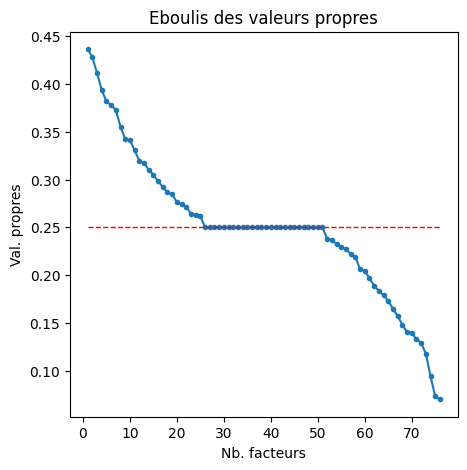

In [31]:
#éboulis des v.p.
fix,ax = plt.subplots(figsize=(5,5))
ax.plot(range(1,Hmax+1),acm.eig_[0],".-")
ax.set_xlabel("Nb. facteurs")
ax.set_ylabel("Val. propres")
plt.title("Eboulis des valeurs propres")
#seuil - Règle de Kaiser
ax.plot([1,Hmax],[1/p,1/p],"r--",linewidth=1)
plt.show()

*Diagramme d'éboulis*. Représentation graphique ayant pour but d'identifier un point d'inflexion dans une courbe de la variance. Le nom donné à ce type de graphique vient de la ressemblance de la courbe avec le profil des éboulis (scree) au bas d'une falaise. [DataFranca, Diagramme d'éboulis, 2024](https://datafranca.org/wiki/index.php?title=Diagramme_d%27%C3%A9boulis&oldid=93502)

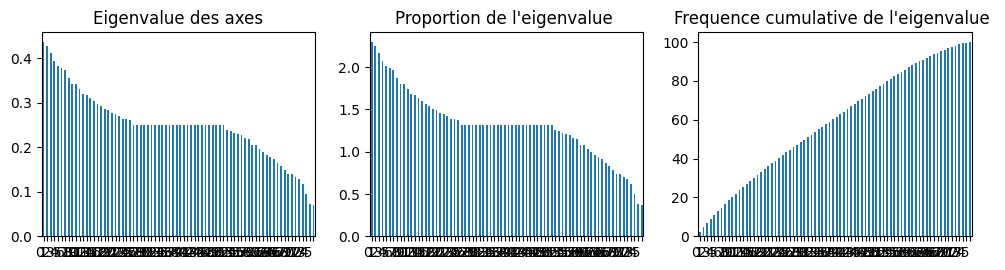

In [32]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion de l'eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

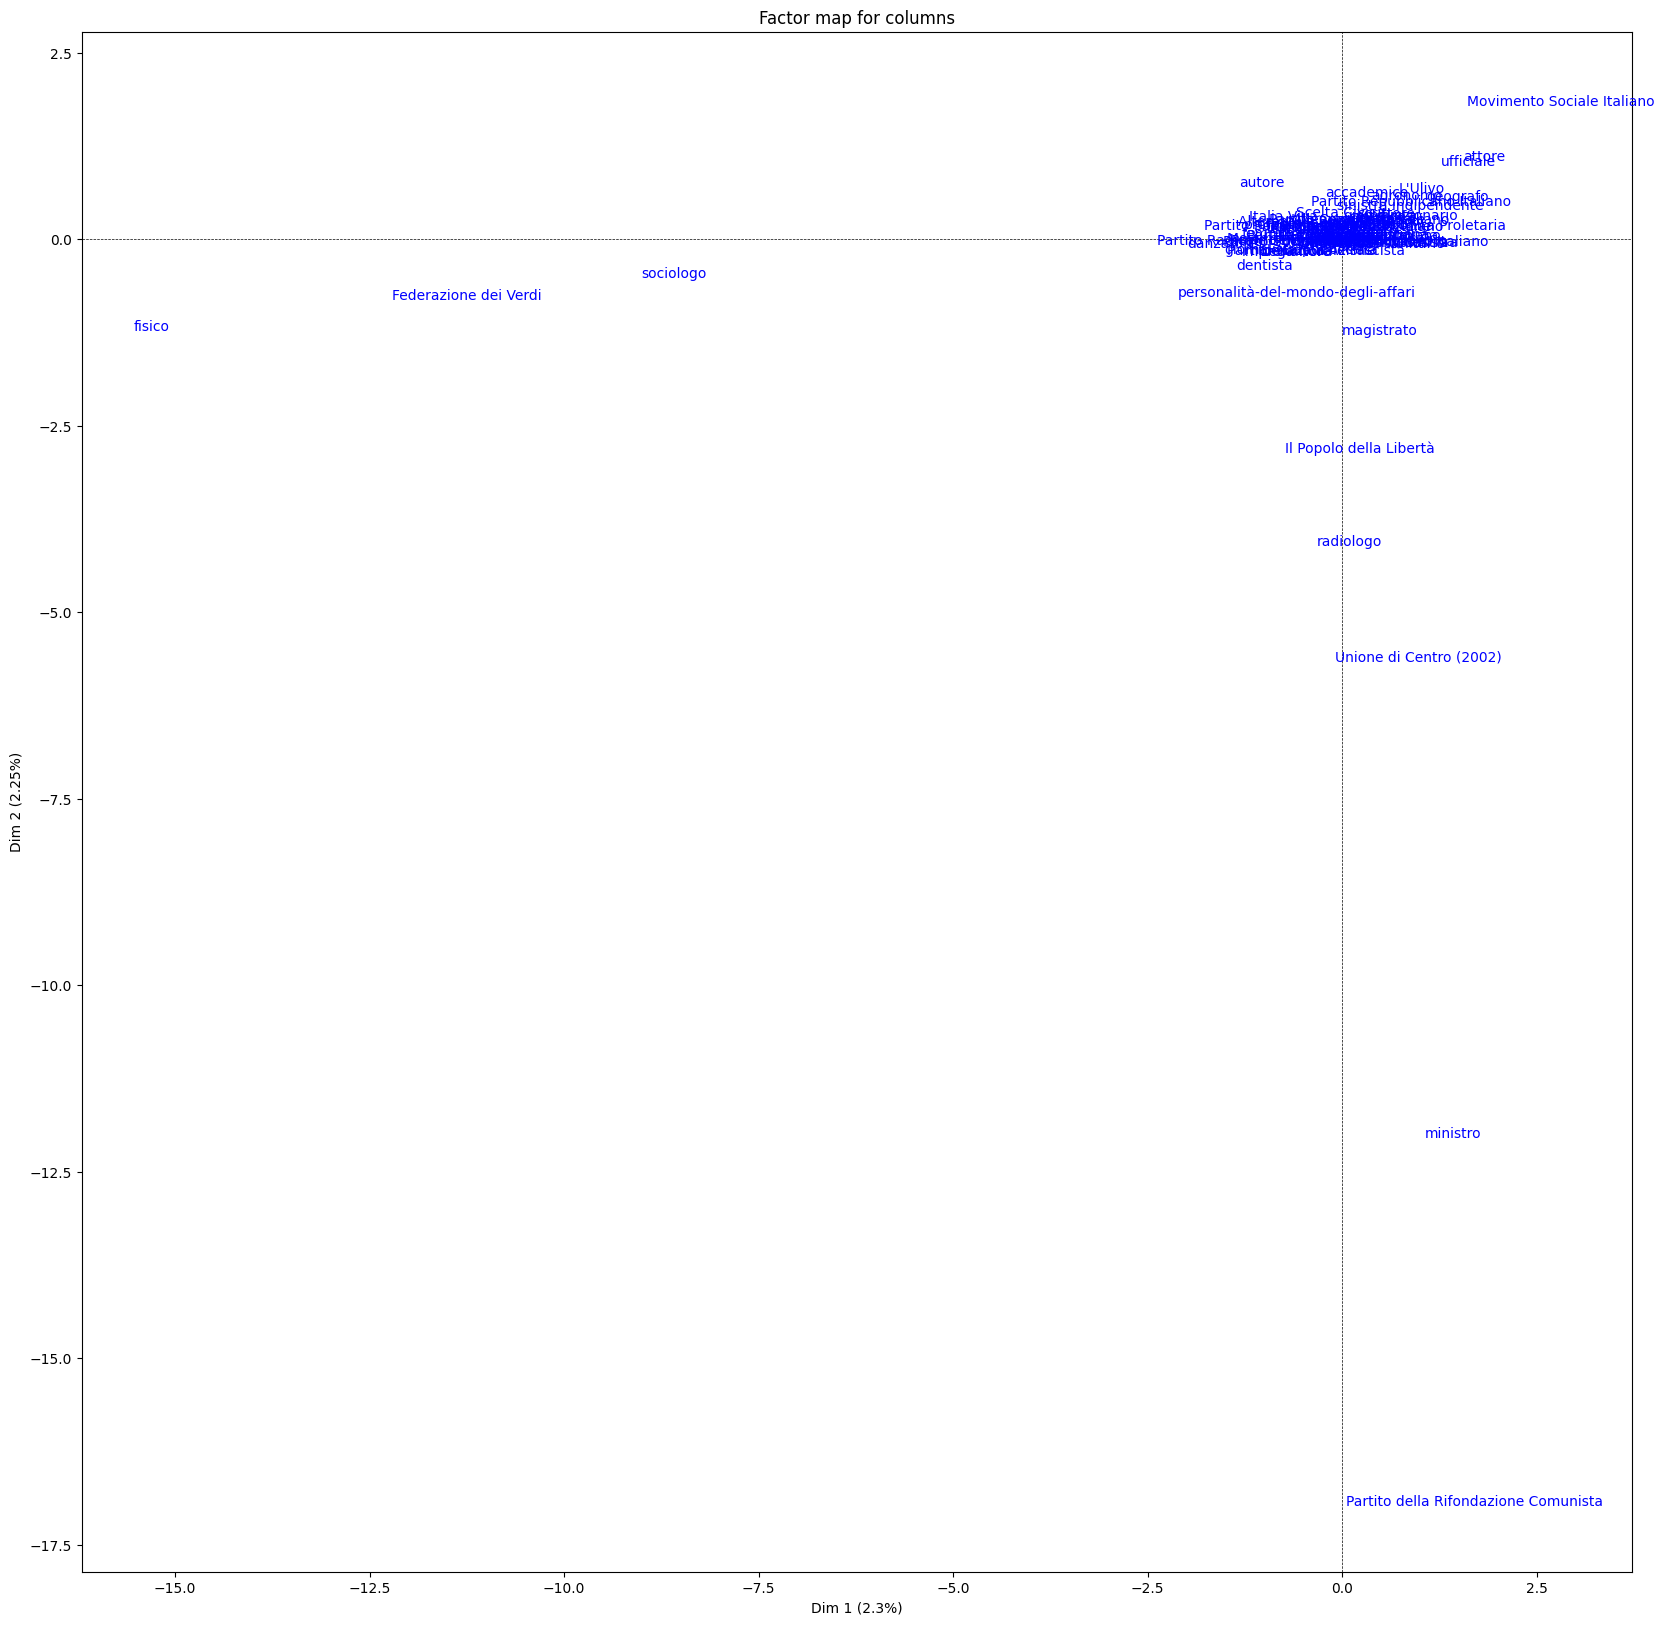

In [33]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=2, figsize=(20,20))

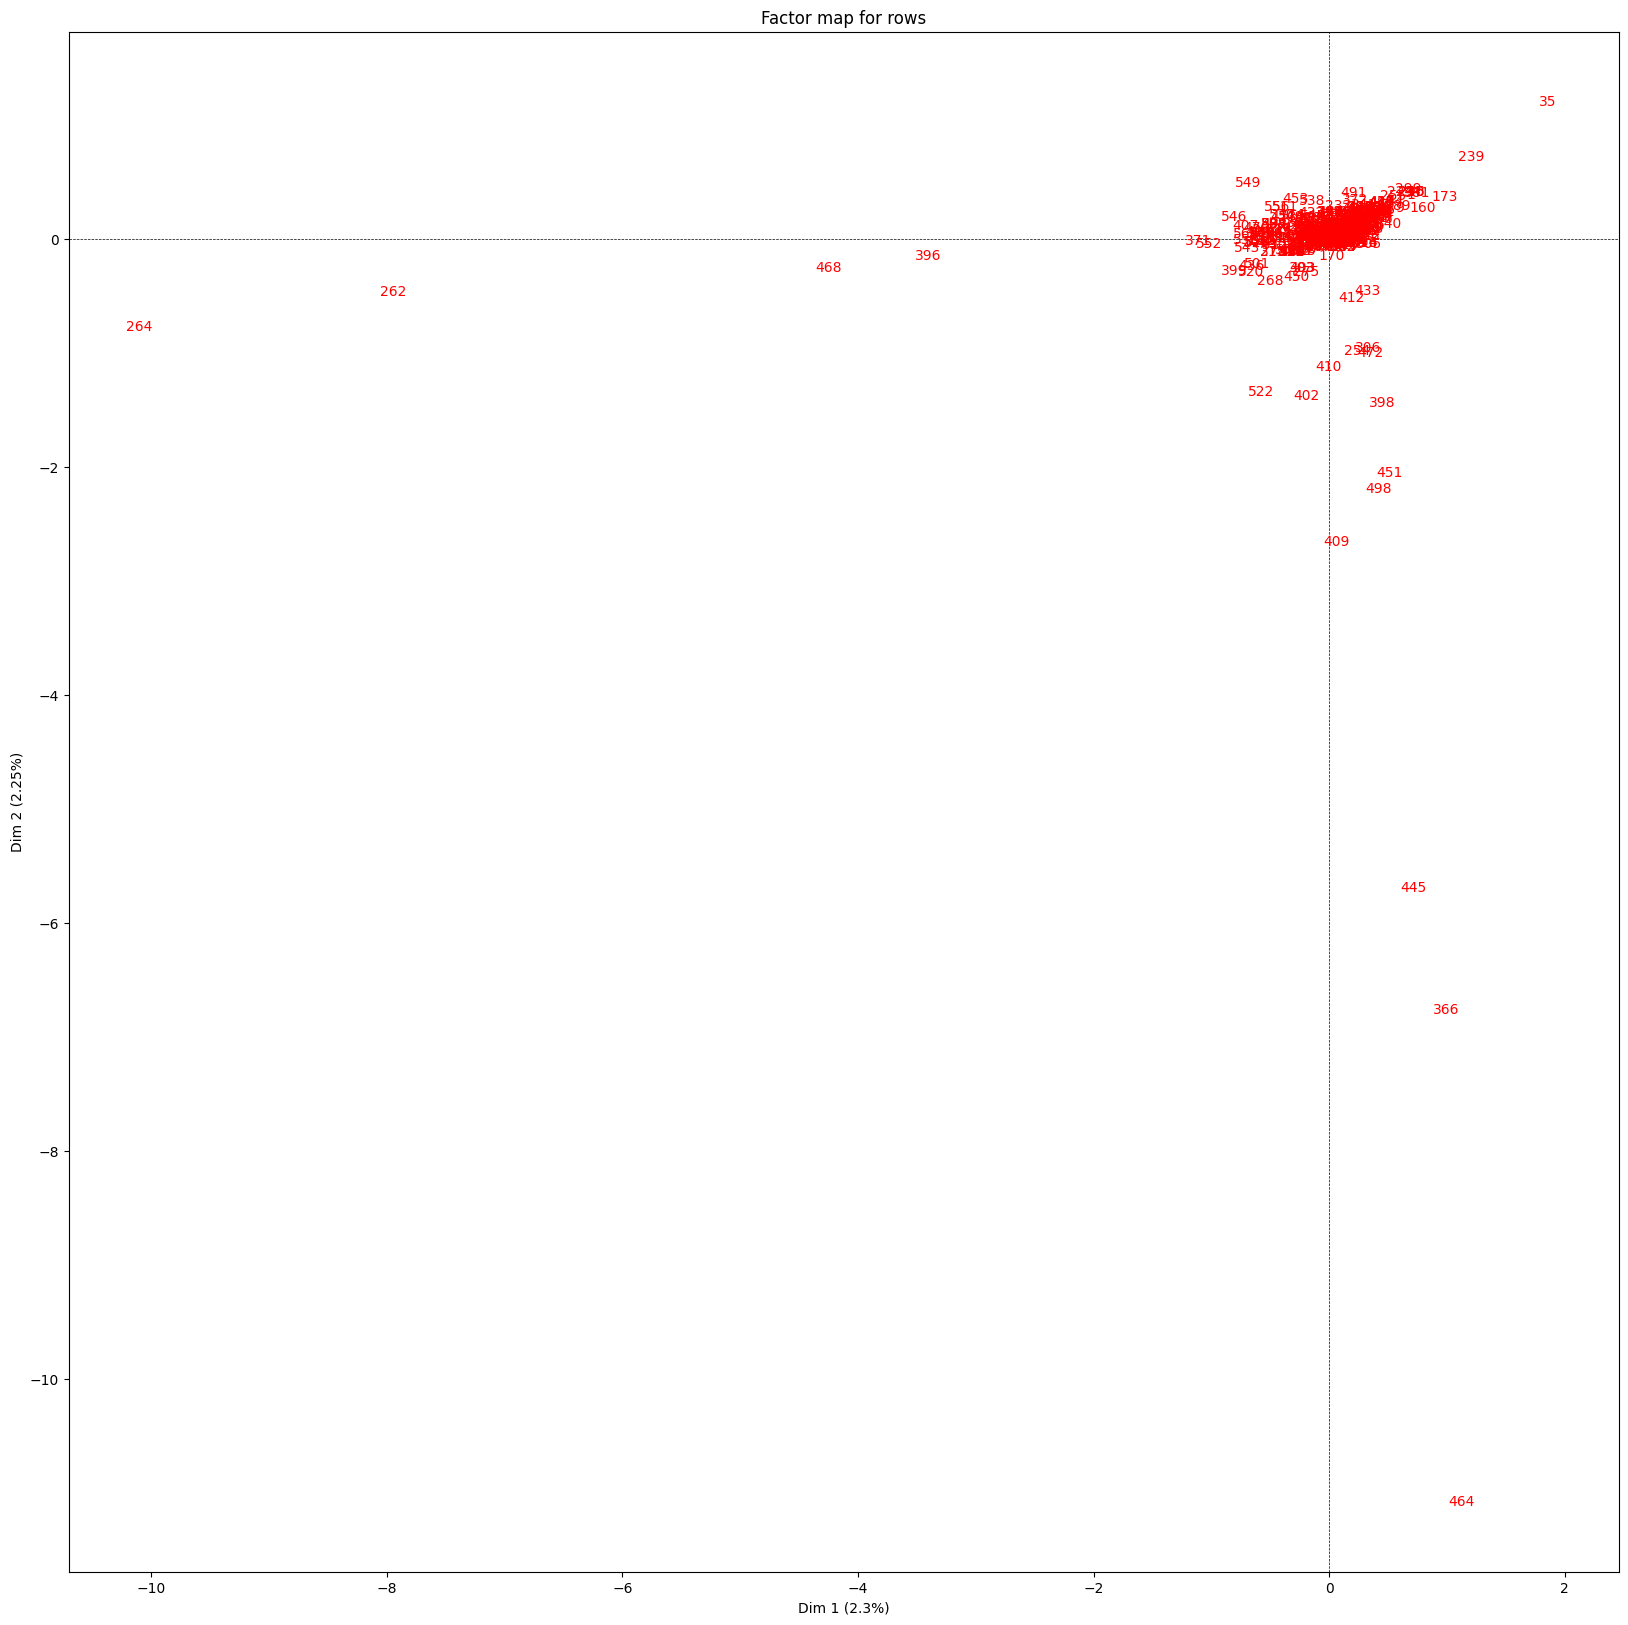

In [34]:
# Mapping des points lignes: individus
acm.mapping_row(num_x_axis=1, num_y_axis=2, figsize=(20,20))

## Représenter les individus

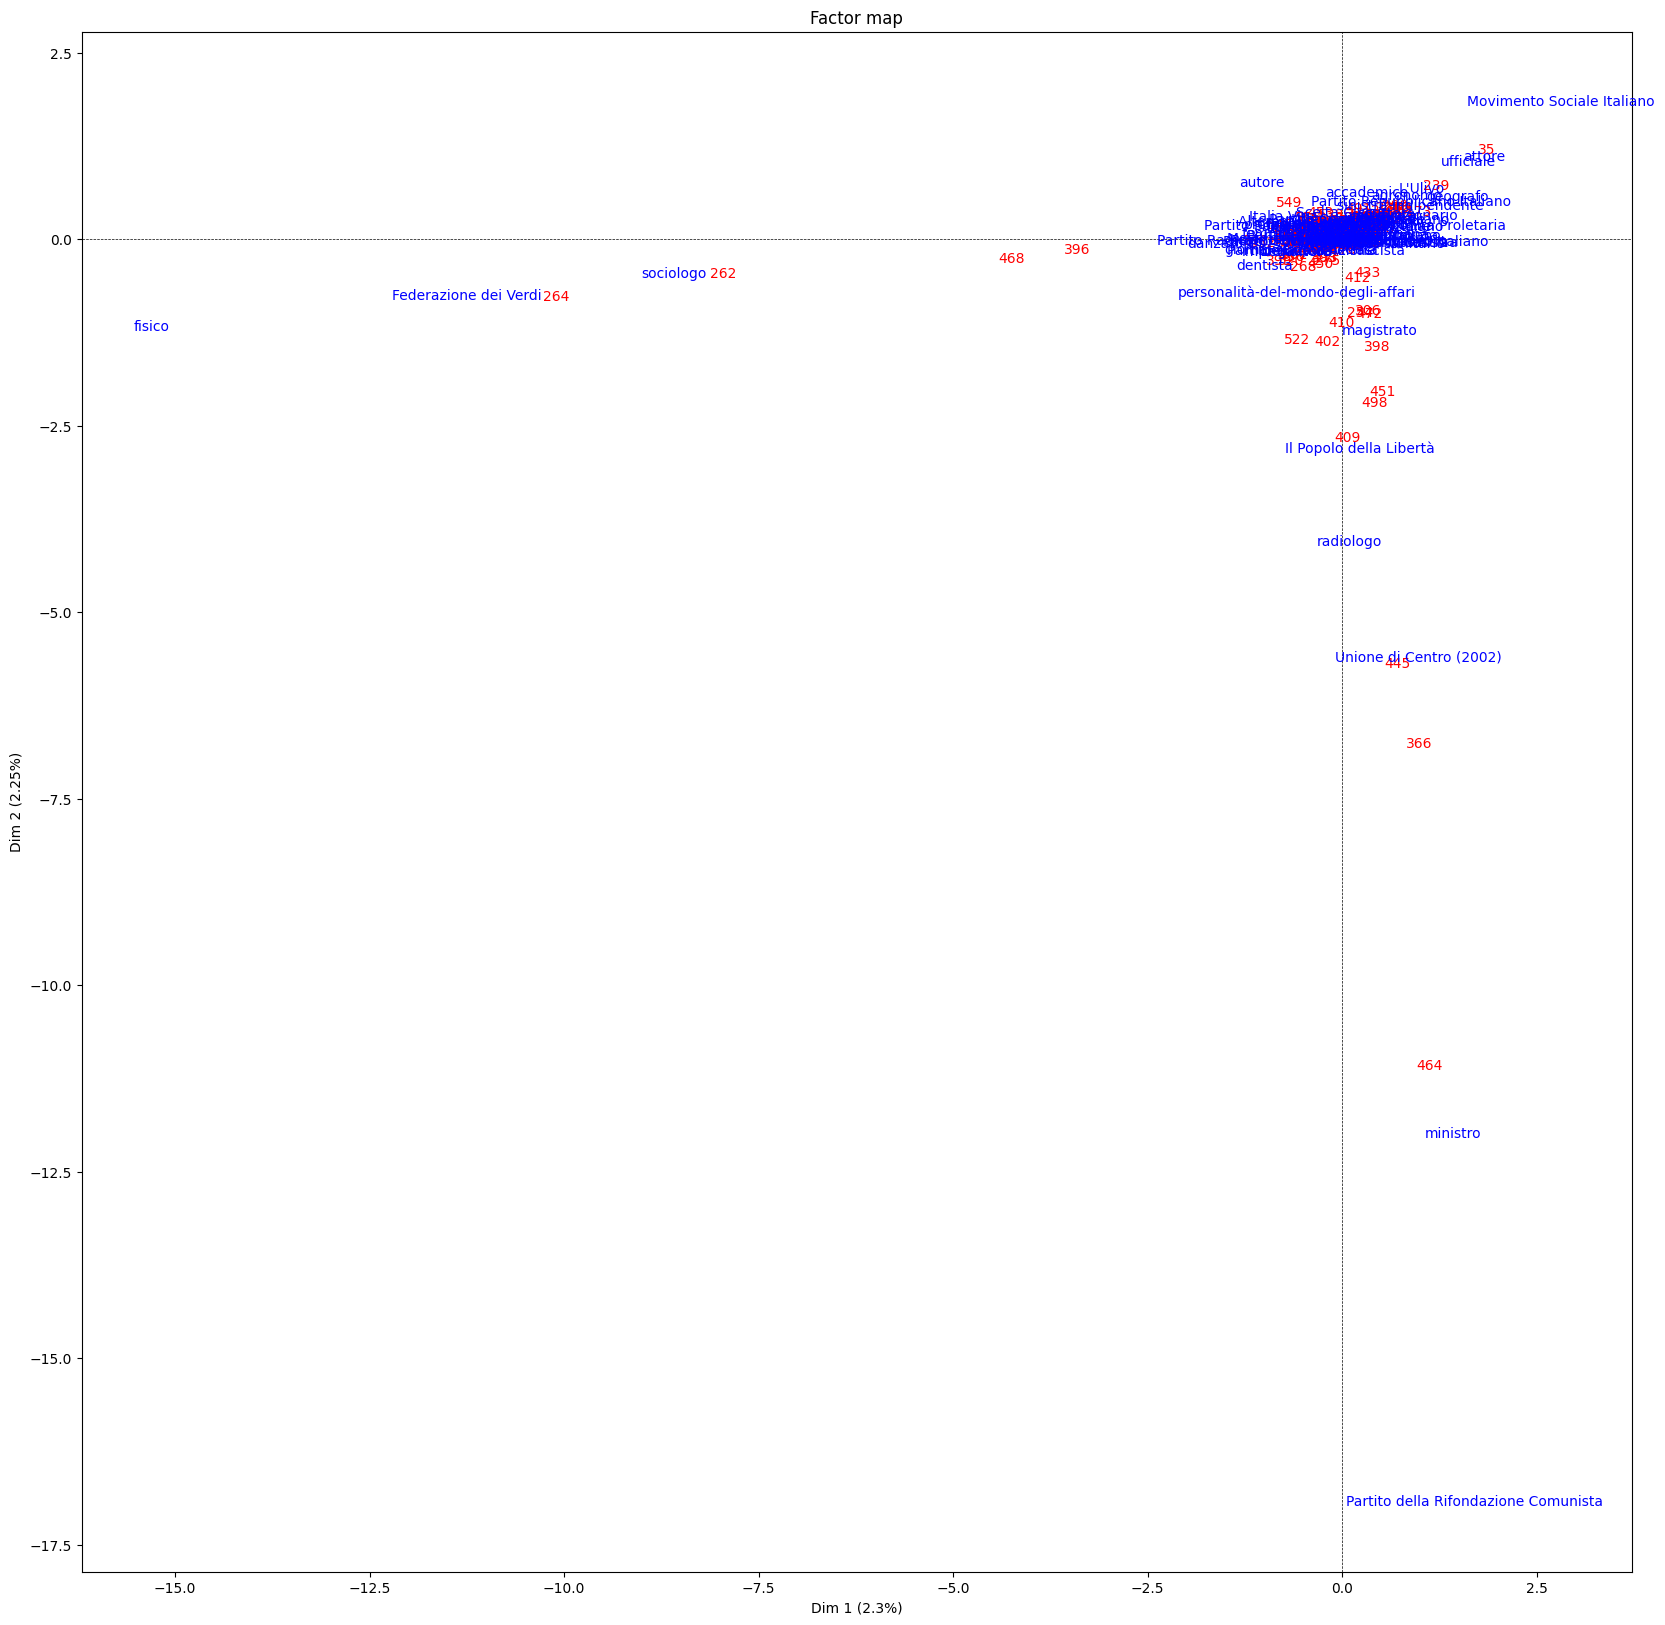

In [35]:
# Mapping simultané des points lignes et colonnes
# Les paramètres de la méthode mapping indiquent que ce sont les axes 1 et 2 qui sont ici représentés
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [36]:
### Inspect individuals
df_pm.loc[[376, 371, 289]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,codedSecOccupation
376,http://www.wikidata.org/entity/Q47547,Antonio Di Pietro,1950.0,maschio,Montenero di Bisaccia,POINT (14.783333 41.95),http://www.wikidata.org/entity/Q277822,1941-1950,13.0,Molise,14.0,14.0,Sud,1985.0,1967-1986,466,politico,avvocato,giudice,mancante,Italia dei Valori,mancante,466,mancante,avvocato
371,http://www.wikidata.org/entity/Q50002,Emma Bonino,1948.0,femmina,Bra,POINT (7.85 44.7),http://www.wikidata.org/entity/Q18382,1941-1950,0.0,Piemonte,1.0,1.0,Nord,1983.0,1967-1986,475,politico,mancante,mancante,mancante,Partito Radicale,mancante,475,mancante,mancante
289,http://www.wikidata.org/entity/Q3840174,Luigi Spaventa,1934.0,maschio,Roma,POINT (12.482778 41.893056),http://www.wikidata.org/entity/Q220,1931-1940,11.0,Lazio,12.0,12.0,Centro,1969.0,1967-1986,364,politico,economista,mancante,mancante,sinistra indipendente,mancante,364,mancante,economista


## Add the activity periods as supplementary illustrative values

In [37]:
#isoler les variables supplémentaires (ou illustratives)
df_suppl = df_pm[['periodsActivity']]
print(df_suppl.columns)
df_suppl.head(2)

Index(['periodsActivity'], dtype='object')


,periodsActivity
0,1907-1926
1,1907-1926


In [38]:
info_lig = acm.row_topandas()
info_lig[:2]

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_coord_dim38,row_coord_dim39,row_coord_dim40,row_coord_dim41,row_coord_dim42,row_coord_dim43,row_coord_dim44,row_coord_dim45,row_coord_dim46,row_coord_dim47,row_coord_dim48,row_coord_dim49,row_coord_dim50,row_coord_dim51,row_coord_dim52,row_coord_dim53,row_coord_dim54,row_coord_dim55,row_coord_dim56,row_coord_dim57,row_coord_dim58,row_coord_dim59,row_coord_dim60,row_coord_dim61,row_coord_dim62,row_coord_dim63,row_coord_dim64,row_coord_dim65,row_coord_dim66,row_coord_dim67,row_coord_dim68,row_coord_dim69,row_coord_dim70,row_coord_dim71,row_coord_dim72,row_coord_dim73,row_coord_dim74,row_coord_dim75,row_coord_dim76,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_contrib_dim38,row_contrib_dim39,row_contrib_dim40,row_contrib_dim41,row_contrib_dim42,row_contrib_dim43,row_contrib_dim44,row_contrib_dim45,row_contrib_dim46,row_contrib_dim47,row_contrib_dim48,row_contrib_dim49,row_contrib_dim50,row_contrib_dim51,row_contrib_dim52,row_contrib_dim53,row_contrib_dim54,row_contrib_dim55,row_contrib_dim56,row_contrib_dim57,row_contrib_dim58,row_contrib_dim59,row_contrib_dim60,row_contrib_dim61,row_contrib_dim62,row_contrib_dim63,row_contrib_dim64,row_contrib_dim65,row_contrib_dim66,row_contrib_dim67,row_contrib_dim68,row_contrib_dim69,row_contrib_dim70,row_contrib_dim71,row_contrib_dim72,row_contrib_dim73,row_contrib_dim74,row_contrib_dim75,row_contrib_dim76,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37,row_cos2_dim38,row_cos2_dim39,row_cos2_dim40,row_cos2_dim41,row_cos2_dim42,row_cos2_dim43,row_cos2_dim44,row_cos2_dim45,row_cos2_dim46,row_cos2_dim47,row_cos2_dim48,row_cos2_dim49,row_cos2_dim50,row_cos2_dim51,row_cos2_dim52,row_cos2_dim53,row_cos2_dim54,row_cos2_dim55,row_cos2_dim56,row_cos2_dim57,row_cos2_dim58,row_cos2_dim59,row_cos2_dim60,row_cos2_dim61,row_cos2_dim62,row_cos2_dim63,row_cos2_dim64,row_cos2_dim65,row_cos2_dim66,row_cos2_dim67,row_cos2_dim68,row_cos2_dim69,row_cos2_dim70,row_cos2_dim71,row_cos2_dim72,row_cos2_dim73,row_cos2_dim74,row_cos2_dim75,row_cos2_dim76
0,-0.001023,0.045055,-0.207479,-0.26040,0.367717,0.105586,0.465174,0.514302,0.112586,-0.080387,-0.277383,-0.467733,0.314162,-0.144796,-0.770588,0.814671,0.459170,0.450802,-0.815455,0.839678,1.514089,-0.186643,0.337625,0.515434,-2.004808,0.091378,0.411643,0.375949,-0.302508,-0.175144,0.282200,-0.385815

In [39]:
## We merge the two tables.
# Because they have the same order, the coordinates are added to the right individuals
df_supp_lignes = df_suppl.merge(info_lig, left_index=True, right_index=True)
df_supp_lignes.head(2)

,periodsActivity,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_coord_dim38,row_coord_dim39,row_coord_dim40,row_coord_dim41,row_coord_dim42,row_coord_dim43,row_coord_dim44,row_coord_dim45,row_coord_dim46,row_coord_dim47,row_coord_dim48,row_coord_dim49,row_coord_dim50,row_coord_dim51,row_coord_dim52,row_coord_dim53,row_coord_dim54,row_coord_dim55,row_coord_dim56,row_coord_dim57,row_coord_dim58,row_coord_dim59,row_coord_dim60,row_coord_dim61,row_coord_dim62,row_coord_dim63,row_coord_dim64,row_coord_dim65,row_coord_dim66,row_coord_dim67,row_coord_dim68,row_coord_dim69,row_coord_dim70,row_coord_dim71,row_coord_dim72,row_coord_dim73,row_coord_dim74,row_coord_dim75,row_coord_dim76,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_contrib_dim38,row_contrib_dim39,row_contrib_dim40,row_contrib_dim41,row_contrib_dim42,row_contrib_dim43,row_contrib_dim44,row_contrib_dim45,row_contrib_dim46,row_contrib_dim47,row_contrib_dim48,row_contrib_dim49,row_contrib_dim50,row_contrib_dim51,row_contrib_dim52,row_contrib_dim53,row_contrib_dim54,row_contrib_dim55,row_contrib_dim56,row_contrib_dim57,row_contrib_dim58,row_contrib_dim59,row_contrib_dim60,row_contrib_dim61,row_contrib_dim62,row_contrib_dim63,row_contrib_dim64,row_contrib_dim65,row_contrib_dim66,row_contrib_dim67,row_contrib_dim68,row_contrib_dim69,row_contrib_dim70,row_contrib_dim71,row_contrib_dim72,row_contrib_dim73,row_contrib_dim74,row_contrib_dim75,row_contrib_dim76,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37,row_cos2_dim38,row_cos2_dim39,row_cos2_dim40,row_cos2_dim41,row_cos2_dim42,row_cos2_dim43,row_cos2_dim44,row_cos2_dim45,row_cos2_dim46,row_cos2_dim47,row_cos2_dim48,row_cos2_dim49,row_cos2_dim50,row_cos2_dim51,row_cos2_dim52,row_cos2_dim53,row_cos2_dim54,row_cos2_dim55,row_cos2_dim56,row_cos2_dim57,row_cos2_dim58,row_cos2_dim59,row_cos2_dim60,row_cos2_dim61,row_cos2_dim62,row_cos2_dim63,row_cos2_dim64,row_cos2_dim65,row_cos2_dim66,row_cos2_dim67,row_cos2_dim68,row_cos2_dim69,row_cos2_dim70,row_cos2_dim71,row_cos2_dim72,row_cos2_dim73,row_cos2_dim74,row_cos2_dim75,row_cos2_dim76
0,1907-1926,-0.001023,0.045055,-0.207479,-0.26040,0.367717,0.105586,0.465174,0.514302,0.112586,-0.080387,-0.277383,-0.467733,0.314162,-0.144796,-0.770588,0.814671,0.459170,0.450802,-0.815455,0.839678,1.514089,-0.186643,0.337625,0.515434,-2.004808,0.091378,0.411643,0.375949,-0.302508,-0

### Plot dim1-dim2

In [40]:
#positionnement d'individus
coord = df_supp_lignes[['periodsActivity','row_coord_dim1', 'row_coord_dim2']].copy()
print(len(coord))
coord.head(2)

561


,periodsActivity,row_coord_dim1,row_coord_dim2
0,1907-1926,-0.001023,0.045055
1,1907-1926,0.694079,0.394966


In [41]:

#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim1', 'row_coord_dim2'],index='periodsActivity',aggfunc='mean')
coord_fact


,row_coord_dim1,row_coord_dim2
periodsActivity,,
1907-1926,0.172924,0.089244
1927-1946,0.117817,0.060721
1947-1966,0.160792,0.086409
1967-1986,-0.118027,-0.038601
1987-2006,-0.097420,-0.173201
2007-2026,-0.319404,0.076091


In [42]:

#corrigés par la racine carrée des valeurs propres
# computed barycenters on 2 dimensions (row_coord_dim1 and row_coord_dim2): [:2]
coord_fact = coord_fact/np.sqrt(acm.eig_[0][:2])
print(coord_fact)

                 row_coord_dim1  row_coord_dim2
periodsActivity                                
1907-1926              0.261723        0.136378
1927-1946              0.178318        0.092791
1947-1966              0.243362        0.132046
1967-1986             -0.178636       -0.058988
1987-2006             -0.147447       -0.264678
2007-2026             -0.483424        0.116278


In [43]:
MCA.mapping_col = cal.custom_mapping_col

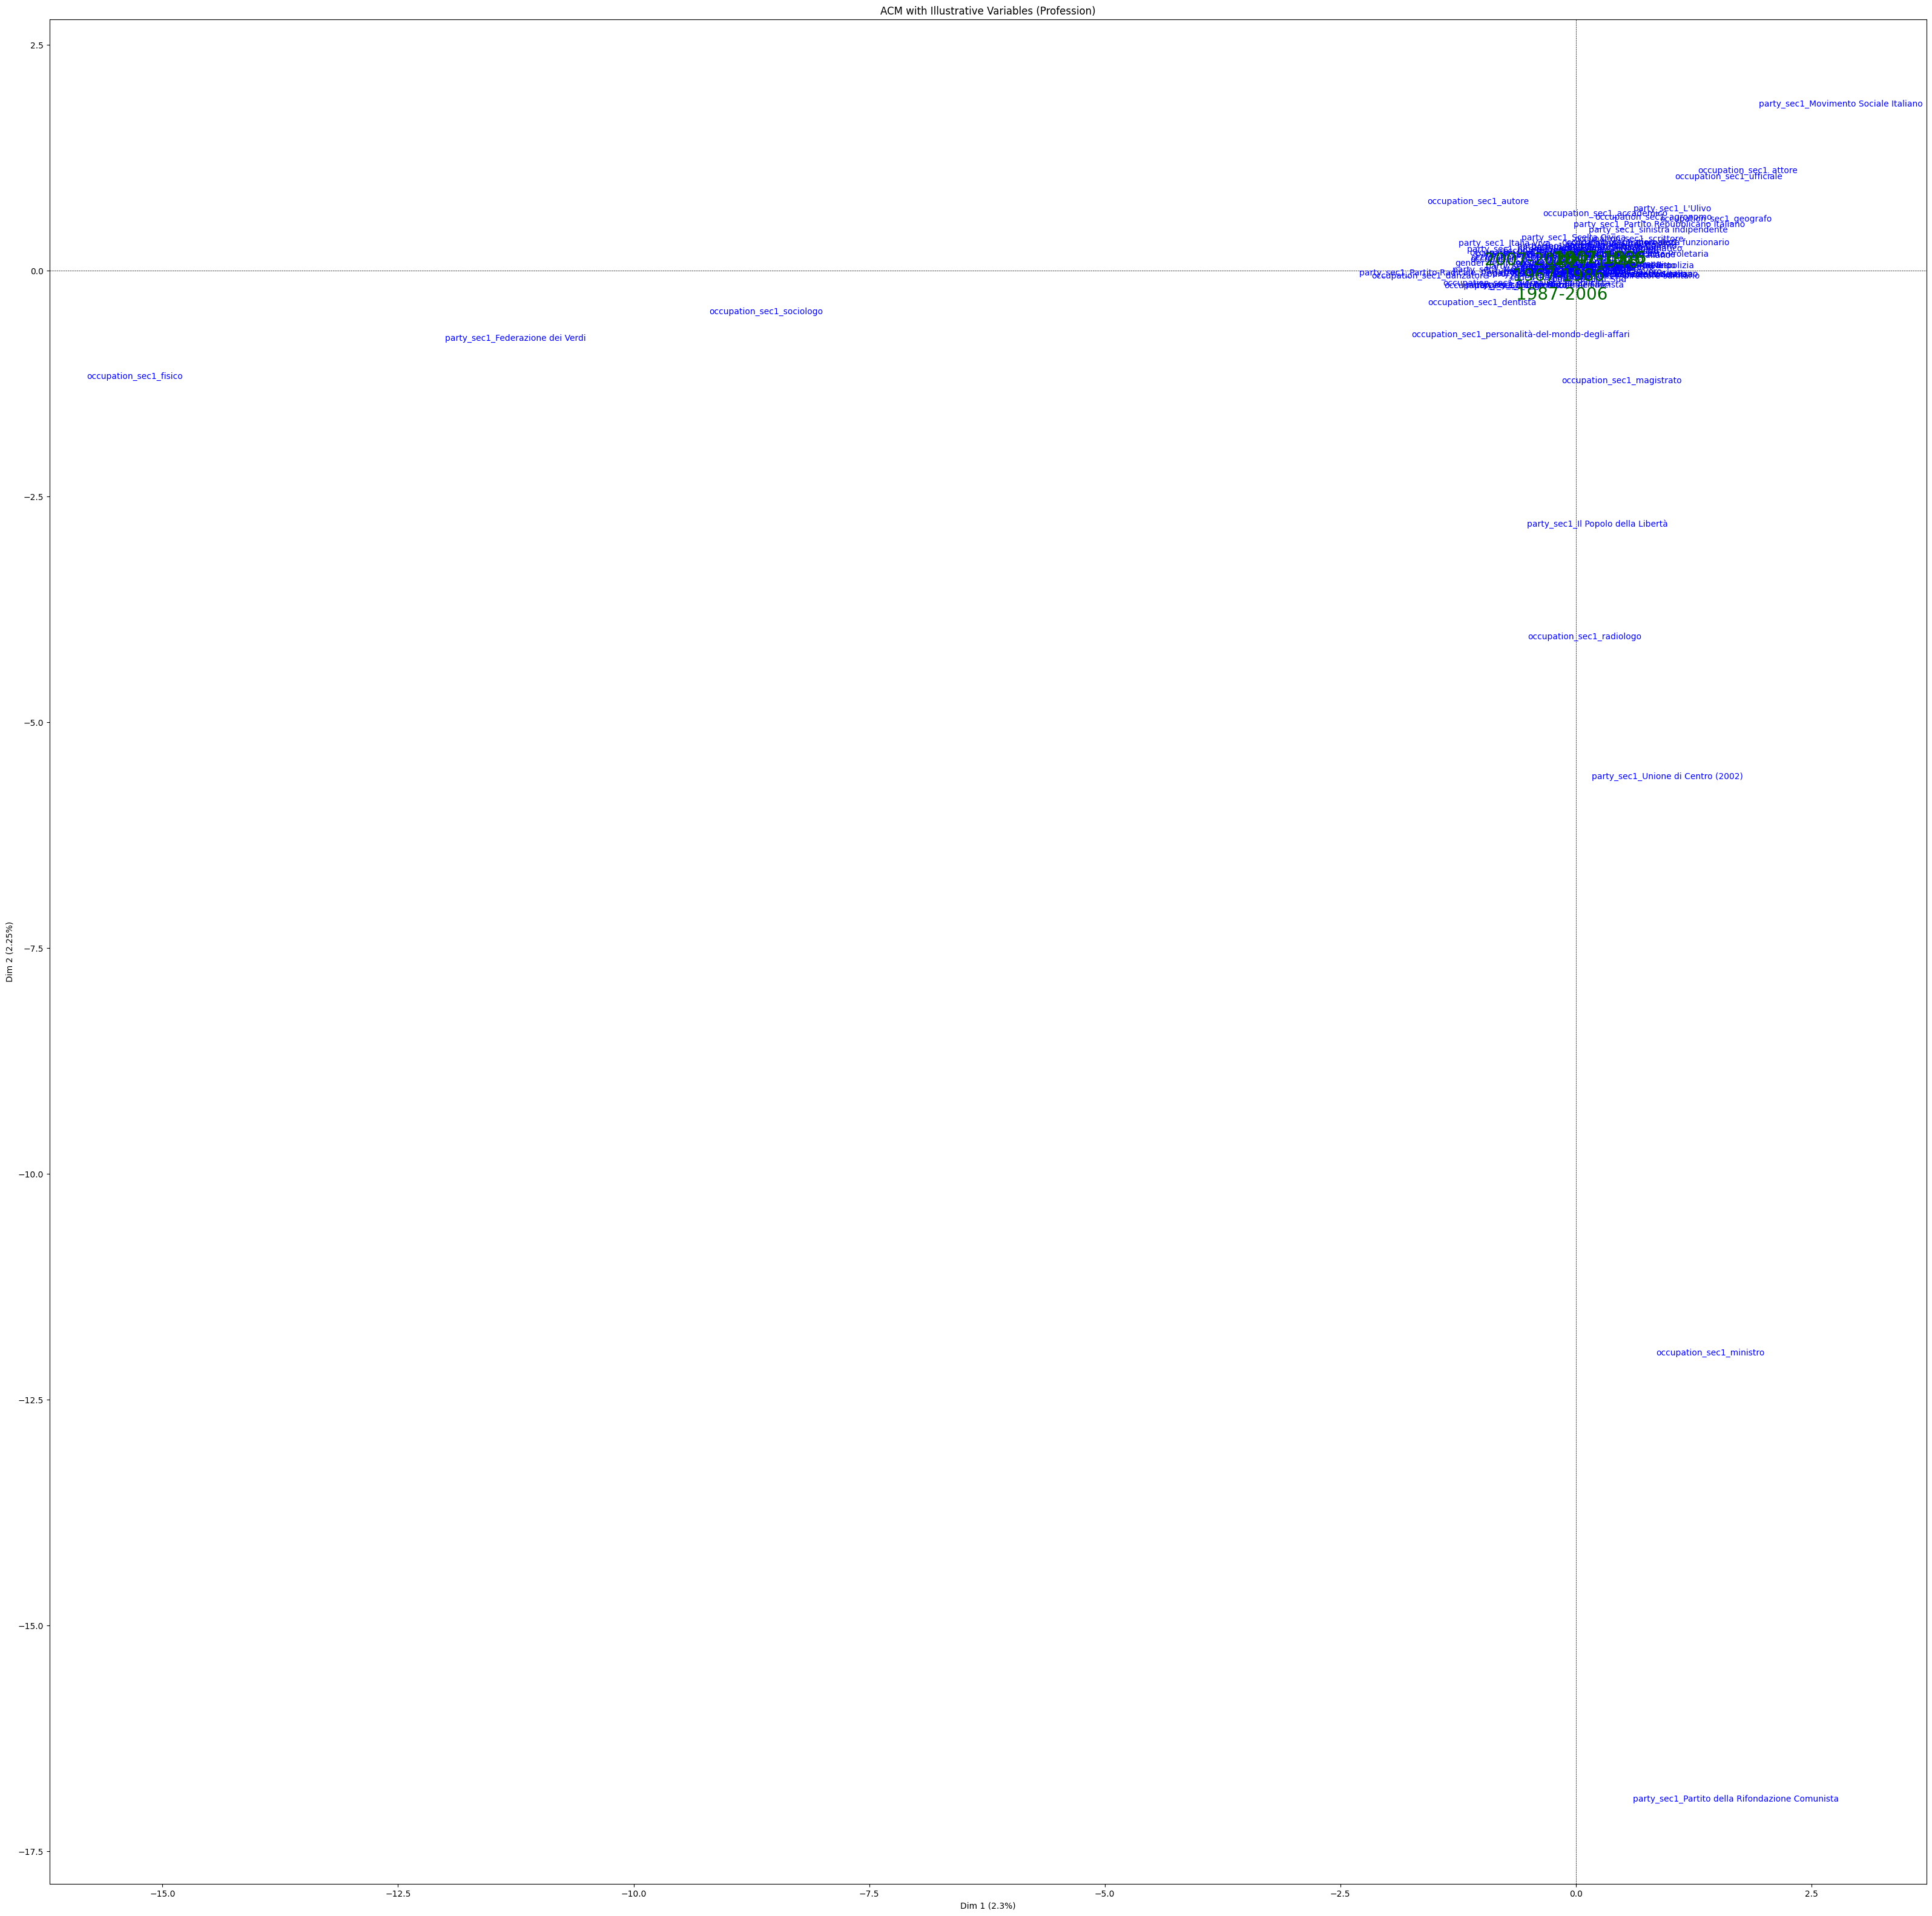

In [44]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(40, 40))

# Plot ACM on ax
acm.mapping_col(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# Add your additional layer

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()


## Prepare file for cluster analysis

Given that the interpretation of the MCA is quite difficult, given the sparse nature of the variables, we will test the [K-means clustering method](da5-MCA-clusters.ipynb) on the results of the MCA in order to detect significant profiles.

We therefore export here the coded and prepared data to a [dedicated CSV file](da_data/da5-MCA-clusters.csv).

In [45]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,codedSecOccupation
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,355,politico,sindacalista,mancante,mancante,Partito Socialista Italiano,mancante,355,mancante,sindacalista
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,461,politico,diplomatico,mancante,mancante,Partito Repubblicano Italiano,mancante,461,mancante,diplomatico
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0,Nord,1909.0,1907-1926,331,politico,mancante,mancante,mancante,Partito Popolare Italiano,mancante,331,mancante,mancante


In [46]:
file_address='da5-MCA-cluster(2).csv'
df_pm.to_csv(file_address, index=False)

In [47]:
import pandas as pd

# 1. Carica il nuovo file CSV
csv_cluster_address = 'da5-MCA-cluster(2).csv'
df_cluster = pd.read_csv(csv_cluster_address)

# 2. Elimina la colonna 'party_main'
# Usiamo axis=1 per indicare che stiamo eliminando una colonna (axis=0 è per le righe)
# Usiamo inplace=True per applicare la modifica direttamente sul DataFrame corrente
df_cluster.drop(columns=['party_main','notes', 'party_sec2'], inplace=True)

# Verifica il risultato mostrando le prime righe
df_cluster.head()

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_sec1,fk_person,codedSecOccupation
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,355,politico,sindacalista,mancante,Partito Socialista Italiano,355,sindacalista
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,461,politico,diplomatico,mancante,Partito Repubblicano Italiano,461,diplomatico
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0,Nord,1909.0,1907-1926,331,politico,mancante,mancante,Partito Popolare Italiano,331,mancante
3,http://www.wikidata.org/entity/Q1242,Luigi Einaudi,1874.0,maschio,Carrù,POINT (7.883333 44.483333),http://www.wikidata.org/entity/Q19372,1871-1880,0.0,Piemonte,1.0,1.0,Nord,1909.0,1907-1926,41,politico,avvocato,giornalista,Partito Liberale Italiano,41,avvocato
4,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873.0,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,5.0,Friuli-Venezia Giulia,6.0,6.0,Nord,1908.0,1907-1926,358,politico,avvocato,mancante,Partito Democratico del Lavoro,358,avvocato


In [48]:
import pandas as pd

# 1. Carichiamo il DataFrame (es. quello dei cluster o delle feature)
df_cluster = pd.read_csv('da5-MCA-cluster(2).csv')

# 2. Definiamo la tua funzione ottimizzata (con un controllo per i valori non testuali)
def codeSecparty(party):
    # Se il valore è nullo o non è una stringa, lo lasciamo così com'è o mettiamo "mancante"
    if pd.isna(party) or not isinstance(party, str):
        return "mancante"
    
    if ('Partito Democratico' in party 
        or 'Centro Democratico' in party 
        or 'Partito Democratico del Lavoro' in party 
        or 'Partito Socialista Italiano' in party 
        or 'Partito Socialista Democratico Italiano' in party 
        or 'Partito Repubblicano Italiano' in party
        or 'Democratici di Sinistra' in party 
        or 'Partito Comunista Italiano' in party 
        or "Partito d'Azione" in party 
        or "Federazione dei Verdi" in party 
        or "L'Ulivo" in party 
        or 'Partito Radicale' in party 
        or 'Rosa nel Pugno' in party 
        or 'Partito della Rifondazione Comunista' in party 
        or 'Partito Socialista Italiano di Unità Proletaria' in party 
        or 'sinistra indipendente' in party):
        output = 'Sinistra/Centro Sinistra'
        
    elif ('Forza Italia' in party 
          or 'Partito Liberale Italiano' in party 
          or 'Lega Nord' in party 
          or 'Alleanza Nazionale' in party 
          or 'Il Popolo della Libertà' in party 
          or "Fratelli d'Italia" in party 
          or 'Alternativa Popolare' in party 
          or 'Nuovo Centrodestra' in party 
          or 'Identità e Azione' in party):
        output = 'Destra/Centro Destra'
        
    elif ('Movimento 5 Stelle' in party 
          or 'Democrazia Cristiana' in party 
          or 'Scelta Civica' in party 
          or 'Partito Popolare Italiano' in party 
          or 'Italia Viva' in party 
          or 'Unione di Centro (2002)' in party 
          or 'Centro Democratico' in party 
          or 'Italia dei Valori' in party 
          or 'Movimento Sociale Italiano' in party 
          or 'Partito Nazionale Fascista' in party):
        output = 'Centro'
        
    else:
        output = party
        
    return output

# 3. Creiamo la nuova colonna applicando la funzione.
# NOTA: Sostituisci 'party_originale' con il vero nome della colonna nel tuo CSV
df_cluster['codedSecparty'] = df_cluster['party_sec1'].apply(codeSecparty)

# Verifica che la nuova colonna sia stata aggiunta correttamente
df_cluster[['party_sec1', 'codedSecparty']].head()

,party_sec1,codedSecparty
0,Partito Socialista Italiano,Sinistra/Centro Sinistra
1,Partito Repubblicano Italiano,Sinistra/Centro Sinistra
2,Partito Popolare Italiano,Centro
3,Partito Liberale Italiano,Destra/Centro Destra
4,Partito Democratico del Lavoro,Sinistra/Centro Sinistra


In [49]:
import pandas as pd

# 1. Carica il file originale
csv_filename = 'da5-MCA-cluster(2).csv'
df = pd.read_csv(csv_filename)

# 2. Elimina la colonna che non serve più
if 'party_main' in df.columns:
    df.drop(columns=['party_main'], inplace=True)
if 'party_sec2' in df.columns:
    df.drop(columns=['party_sec2'], inplace=True)
if 'notes' in df.columns:
    df.drop(columns=['notes'], inplace=True)

# 3. Definisci la funzione di ricodifica
def codeSecparty(party):
    if pd.isna(party) or not isinstance(party, str):
        return "mancante"
    
    if ('Partito Democratico' in party 
        or 'Centro Democratico' in party 
        or 'Partito Democratico del Lavoro' in party 
        or 'Partito Socialista Italiano' in party 
        or 'Partito Socialista Democratico Italiano' in party 
        or 'Partito Repubblicano Italiano' in party
        or 'Democratici di Sinistra' in party 
        or 'Partito Comunista Italiano' in party 
        or "Partito d'Azione" in party 
        or "Federazione dei Verdi" in party 
        or "L'Ulivo" in party 
        or 'Partito Radicale' in party 
        or 'Rosa nel Pugno' in party 
        or 'Partito della Rifondazione Comunista' in party 
        or 'Partito Socialista Italiano di Unità Proletaria' in party 
        or 'sinistra indipendente' in party):
        return 'Sinistra/Centro Sinistra'
        
    elif ('Forza Italia' in party 
          or 'Partito Liberale Italiano' in party 
          or 'Lega Nord' in party 
          or 'Alleanza Nazionale' in party 
          or 'Il Popolo della Libertà' in party 
          or "Fratelli d'Italia" in party 
          or 'Alternativa Popolare' in party 
          or 'Nuovo Centrodestra' in party 
          or 'Identità e Azione' in party):
        return 'Destra/Centro Destra'
        
    elif ('Movimento 5 Stelle' in party 
          or 'Democrazia Cristiana' in party 
          or 'Scelta Civica' in party 
          or 'Partito Popolare Italiano' in party 
          or 'Italia Viva' in party 
          or 'Unione di Centro (2002)' in party 
          or 'Centro Democratico' in party 
          or 'Italia dei Valori' in party 
          or 'Movimento Sociale Italiano' in party 
          or 'Partito Nazionale Fascista' in party):
        return 'Centro'
    
    return party

# 4. Applica la funzione per creare la nuova colonna
# NOTA: Sostituisci 'party_originale' con il nome reale della tua colonna (es. 'party' o 'party_sec')
nome_colonna_partiti = 'party_sec1' 

df['codedSecparty'] = df[nome_colonna_partiti].apply(codeSecparty)

# 5. SALVATAGGIO SUL FILE CSV
# Usa index=False per evitare che pandas aggiunga una colonna inutile con i numeri di riga (0, 1, 2...)
df.to_csv(csv_filename, index=False)

print("File CSV aggiornato con successo!")

File CSV aggiornato con successo!


## Split the generations and analyse significant ones

In [50]:
activity_period='2007-2026'
df_pm[df_pm.periods==activity_period].head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,codedSecOccupation


## MCA

In [51]:
data_cat = df_pm[df_pm.periodsActivity==activity_period][['gender', 'coded_Region', 'occupation_sec1', 'party_sec1']]
data_cat.head(3)

,gender,coded_Region,occupation_sec1,party_sec1
525,femmina,Sud,mancante,Movimento 5 Stelle
526,maschio,Nord,mancante,Lega Nord
528,maschio,Nord,mancante,Partito Democratico


In [52]:
DActives=data_cat

In [53]:
acm = MCA(row_labels=DActives.index,var_labels=DActives.columns)
acm.fit(DActives.values)

,n_components,None
,row_labels,"Index([525, 5...dtype='int64')"
,var_labels,Index(['gende...type='object')
,stats,True


In [54]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


Number of factors (approximation tables): 17 

   contribution       freq  freq_cumulee
0      0.574539  13.518557     13.518557
1      0.489404  11.515397     25.033953
2      0.414996   9.764621     34.798575
3      0.385414   9.068557     43.867132
4      0.369760   8.700244     52.567375     contribution      freq  freq_cumulee
12      0.126453  2.975373     93.574326
13      0.104620  2.461658     96.035985
14      0.067706  1.593088     97.629072
15      0.061112  1.437938     99.067011
16      0.039652  0.932989    100.000000


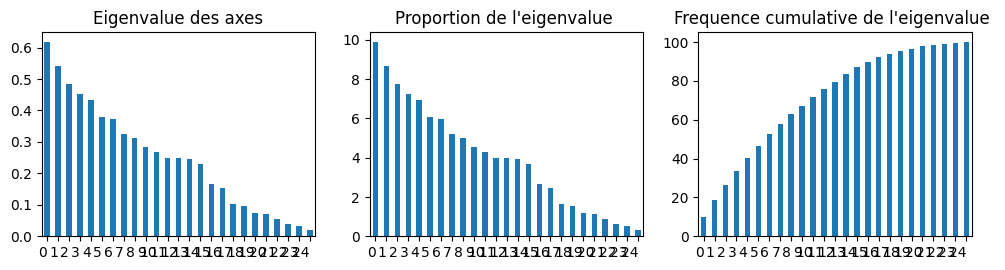

In [106]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion de l'eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

<Axes: title={'center': 'Factor map for columns'}, xlabel='Dim 1 (9.89%)', ylabel='Dim 1 (9.89%)'>

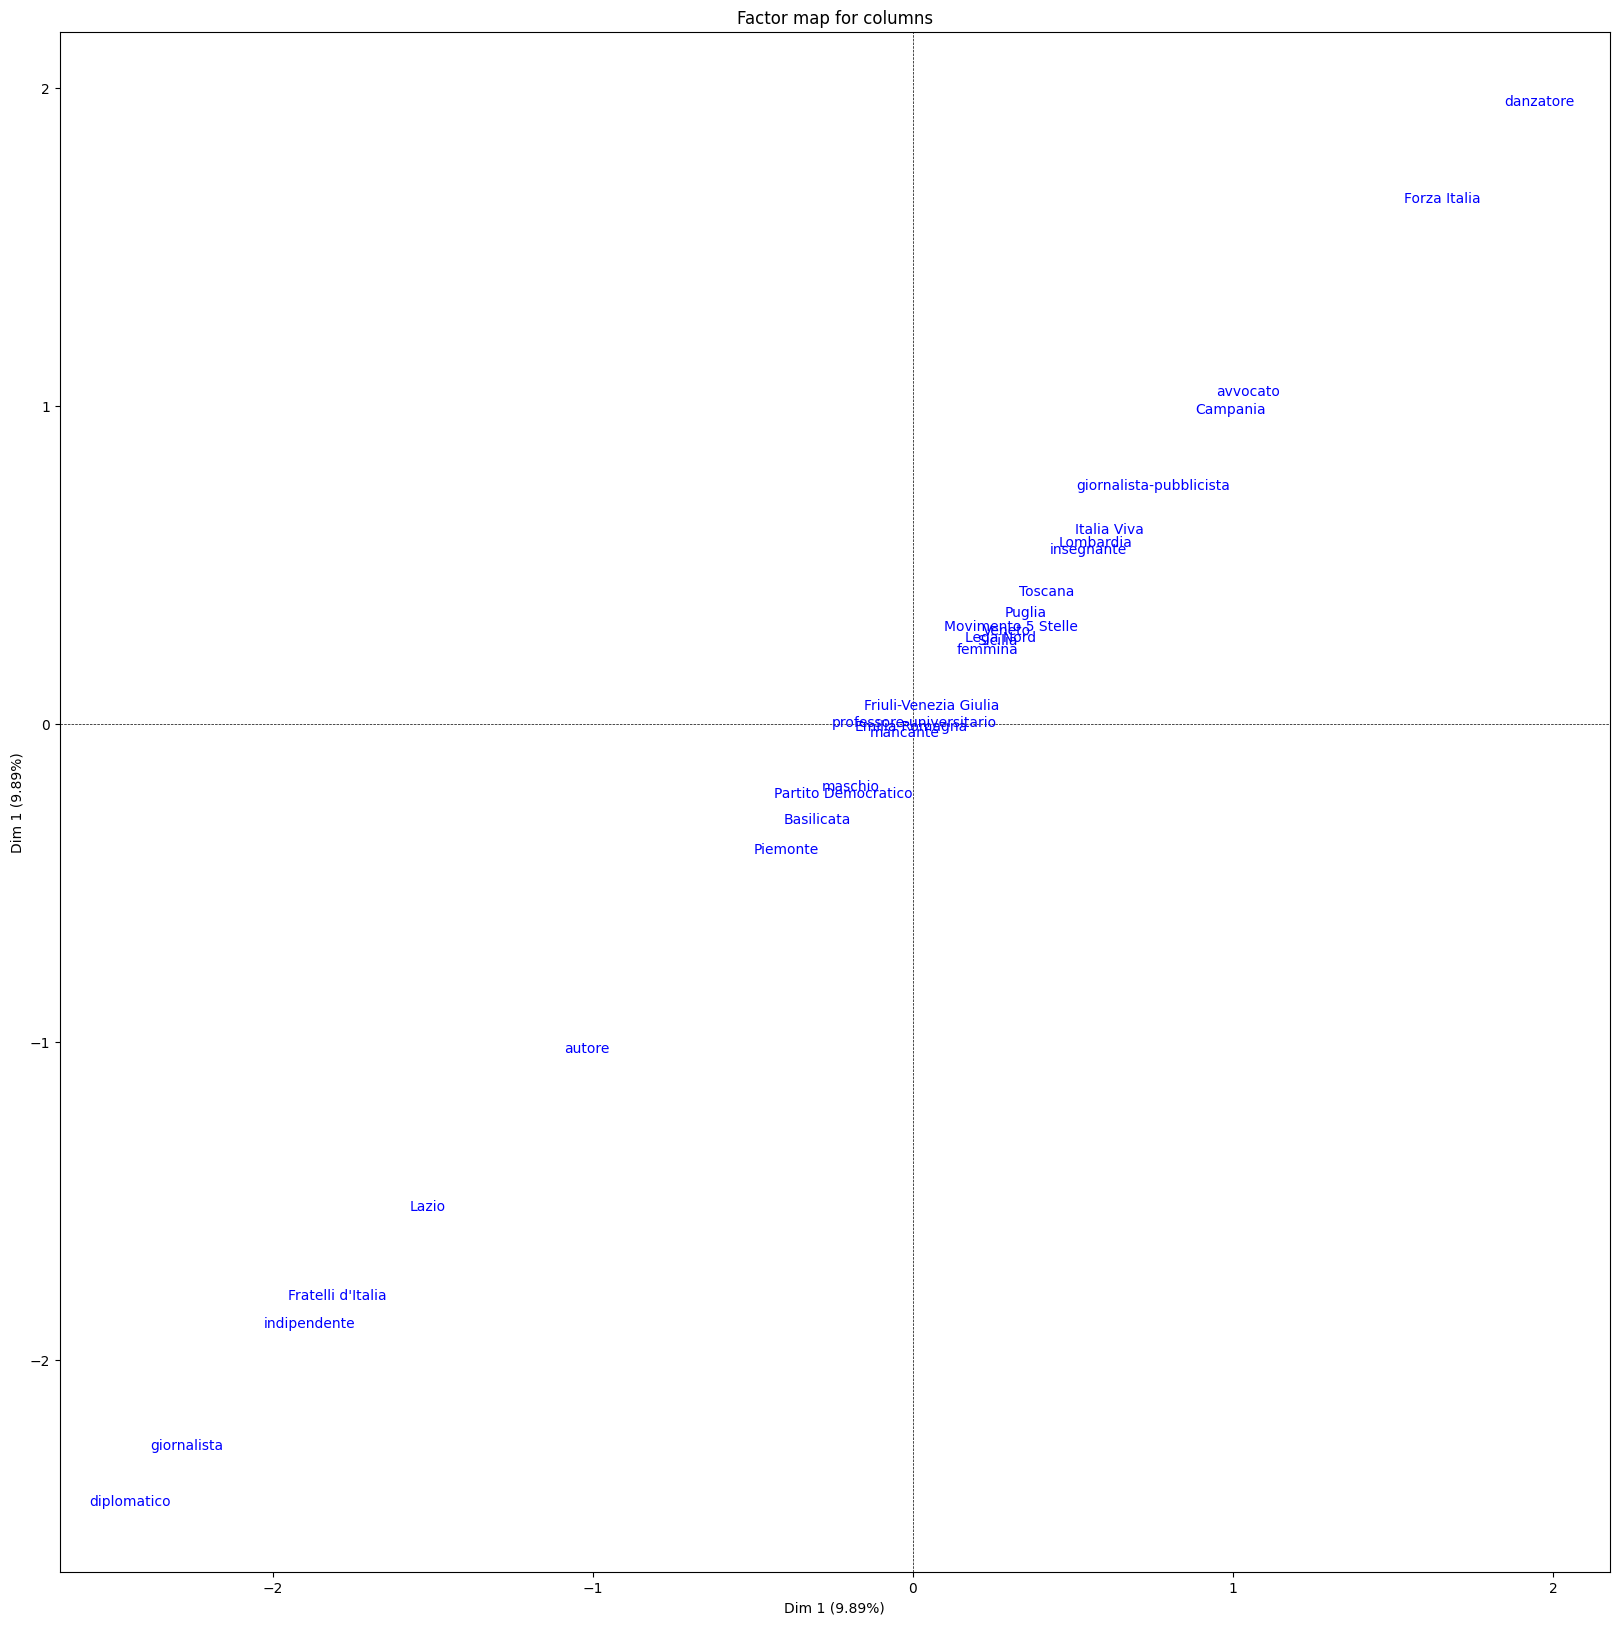

In [107]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=1, figsize=(20,20))

## Représenter les individus

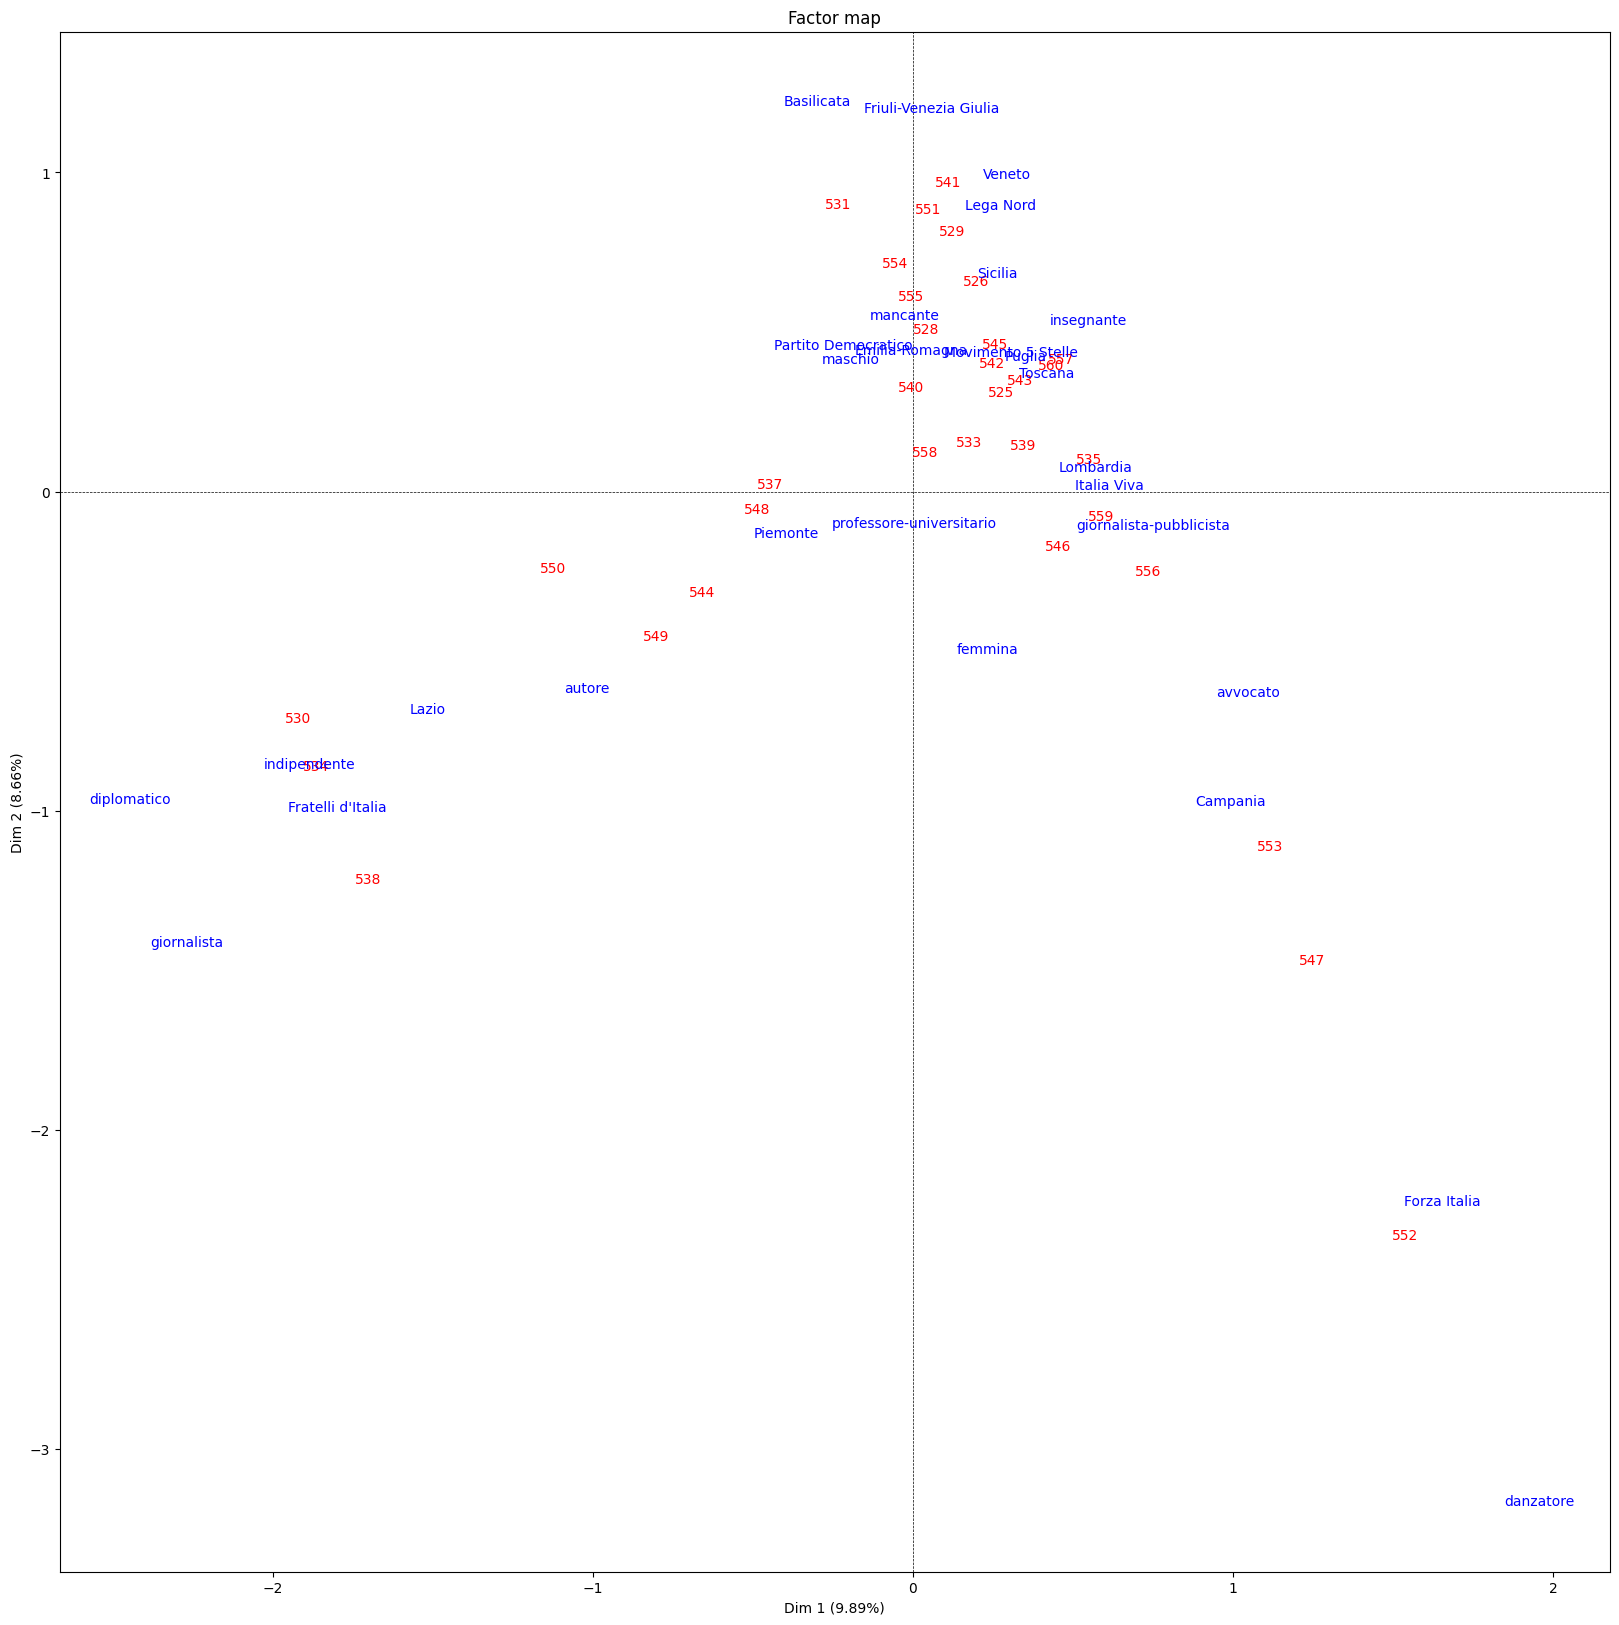

In [108]:
# Mapping simultané des points lignes et colonnes
# Les paramètres de la méthode mapping indiquent que ce sont les axes 1 et 2 qui sont ici représentés
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [109]:
### Inspect individuals
df_pm.loc[[552, 547, 553]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,coded_Region,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_main,party_sec1,party_sec2,fk_person,notes,codedSecOccupation
558,http://www.wikidata.org/entity/Q15936524,Fabiana Dadone,1984.0,femmina,Cuneo,POINT (7.55 44.383333),http://www.wikidata.org/entity/Q5968,1981-1990,0.0,Piemonte,1.0,1.0,Nord,2019.0,2007-2026,90,politico,mancante,mancante,mancante,Movimento 5 Stelle,mancante,90,mancante,mancante
556,http://www.wikidata.org/entity/Q15143059,Maria Elena Boschi,1981.0,femmina,Montevarchi,POINT (11.567867 43.523397),http://www.wikidata.org/entity/Q52089,1981-1990,8.0,Toscana,9.0,9.0,Centro,2016.0,2007-2026,72,politico,avvocato,giurista,mancante,Italia Viva,mancante,72,mancante,avvocato
554,http://www.wikidata.org/entity/Q54250006,Giuseppe Provenzano,1982.0,maschio,San Cataldo,POINT (13.983333 37.483333),http://www.wikidata.org/entity/Q477744,1981-1990,18.0,Sicilia,19.0,19.0,Sud,2017.0,2007-2026,493,politico,mancante,mancante,mancante,Partito Democratico,mancante,493,mancante,mancante
557,http://www.wikidata.org/entity/Q9035872,Riccardo Fraccaro,1981.0,maschio,Montebelluna,POINT (12.038889 45.775278),http://www.wikidata.org/entity/Q46806,1981-1990,4.0,Veneto,5.0,5.0,Nord,2016.0,2007-2026,561,politico,avvocato,mancante,mancante,Movimento 5 Stelle,mancante,561,mancante,avvocato
